# Stazione di Faenza (Lamone) - analisi esplorativa dei livelli idrometrici

Prima esplorazione della serie storica di livello idrometrico della stazione di
Faenza, bacino del Lamone, scaricata dal portale Dext3r di Arpae Emilia-Romagna.

## Obiettivo

Stabilire se la serie e' utilizzabile per addestrare un modello di previsione del
superamento delle soglie di criticita'. Tre domande:

1. **Con che frequenza campiona la stazione**, ed e' cambiata nel tempo?
2. **Quanto e' completa la serie**, e dove si concentrano le lacune?
3. **Quanto sono rari i superamenti di soglia**, cioe' quanto sara' sbilanciato
   il problema di apprendimento?

## Struttura

| Sezione | Contenuto |
|---|---|
| 1 | Caricamento dei file |
| 2 | Frequenza di campionamento |
| 3 | Separazione dei periodi |
| 4 | Rimozione duplicati e griglia regolare |
| 5 | Verifica di integrita' |
| 6 | Valori fuori scala |
| 7 | Lacune |
| 8 | Grafici |
| 9 | Superamenti di soglia |
| 10 | Considerazioni |

## Convenzioni

I valori mancanti **non vengono riempiti**: restano `NaN` su una griglia temporale
regolare. La sequenza dei timestamp e' quindi continua, ma nessun valore viene
inventato. La strategia di imputazione sara' decisa sulla base di questa analisi.

## Dati

| | |
|---|---|
| Stazione | Faenza (RA), 37 m s.l.m. |
| Bacino | Lamone |
| Rete | Arpae-SIMC, portale Dext3r |
| Variabile | livello idrometrico (m) |
| Soglie ufficiali | 3,5 / 4,5 / 6,0 m |

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

import idro

CARTELLA = r"/Users/edoardociorra/Documents/01_PoliTo_MSCS_DSE/00_thesis/01_dati/raw" #da modificare con la directory con i file zip dei dati acquisiti
SOGLIE = {"soglia_0": 3.5, "soglia_1": 4.5, "soglia_2": 6.0}

# intervallo fisicamente plausibile per il livello a questa sezione
LIVELLO_MIN, LIVELLO_MAX = -11, 13 #non vincolante

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
})
pd.set_option("display.width", 120)

## 1. Caricamento

I dati arrivano da Dext3r come zip separati, uno per periodo. Vengono letti tutti
e uniti in un solo dataframe. I file illeggibili vengono segnalati e saltati senza
interrompere il caricamento.

In [20]:
df = idro.carica(CARTELLA)
df.head()

file letti      27
righe           493,832
periodo         2006-01-01 / 2026-08-01
stazioni        Faenza


,stazione,timestamp,valore,file
0,Faenza,2006-01-01 00:00:00+00:00,0.46,dexter-03ac5910-cf3e-4345-8a39-02482188caa3.zip
1,Faenza,2006-01-01 00:30:00+00:00,0.46,dexter-03ac5910-cf3e-4345-8a39-02482188caa3.zip
2,Faenza,2006-01-01 01:00:00+00:00,0.47,dexter-03ac5910-cf3e-4345-8a39-02482188caa3.zip
3,Faenza,2006-01-01 01:30:00+00:00,0.47,dexter-03ac5910-cf3e-4345-8a39-02482188caa3.zip
4,Faenza,2006-01-01 02:00:00+00:00,0.47,dexter-03ac5910-cf3e-4345-8a39-02482188caa3.zip


## 2. Frequenza di campionamento

Prima di costruire qualunque griglia temporale bisogna sapere con che passo
campiona la stazione. Se il passo e' cambiato nel tempo e si applica una griglia
unica, tutti i punti del periodo a frequenza piu' bassa risultano mancanti per
costruzione: un artefatto, non un dato reale.

In [21]:
idro.passo_per_anno(df)

,passo,quota_pct,n_intervalli
anno,,,
2006,0 days 00:30:00,100.0,17519
2007,0 days 00:30:00,100.0,17520
2008,0 days 00:30:00,100.0,17568
2009,0 days 00:30:00,100.0,17520
2010,0 days 00:30:00,100.0,17520
2011,0 days 00:30:00,100.0,17520
2012,0 days 00:30:00,100.0,17568
2013,0 days 00:30:00,100.0,17520
2014,0 days 00:30:00,100.0,17520


In [22]:
taglio = idro.trova_cambio(df)

0 days 00:30:00  fino al 2018-12-31
0 days 00:15:00  dal 2019-01-01


## 3. Separazione dei periodi

I due regimi vengono trattati come serie distinte, ciascuna con la propria griglia.

In [23]:
prima, dopo = idro.separa(df, taglio)

prima    227,962 righe   2006-01-01 / 2018-12-31   passo 0 days 00:30:00
dopo     265,870 righe   2019-01-01 / 2026-08-01   passo 0 days 00:15:00


## 4. Duplicati e griglia regolare

Per ogni periodo: rimozione dei duplicati e riallineamento su griglia regolare.

Fra due righe con lo stesso timestamp vince quella che ha un valore. La colonna
`origine` distingue i due tipi di mancanza:

- `vuoto_nel_file` - il timestamp era presente nel csv ma senza valore
- `assente_dal_file` - il timestamp non compariva affatto

In [24]:
serie_p = idro.prepara(prima)
serie_d = idro.prepara(dopo)

prima  duplicati rimossi    56   griglia   227,904 punti   validi   224,343 (98.44%)   mancanti   3,561
dopo   duplicati rimossi    45   griglia   265,825 punti   validi   254,064 (95.58%)   mancanti  11,761


Da qui in avanti l'analisi prosegue sul **periodo recente** (`serie_d`), che ha la
frequenza di campionamento piu' alta ed e' quindi quello rilevante per una
previsione a breve termine.

In [25]:
serie_d.head()

,stazione,timestamp,valore,origine
0,Faenza,2019-01-01 00:00:00+00:00,0.08,osservato
1,Faenza,2019-01-01 00:15:00+00:00,NaN,vuoto_nel_file
2,Faenza,2019-01-01 00:30:00+00:00,0.08,osservato
3,Faenza,2019-01-01 00:45:00+00:00,NaN,vuoto_nel_file
4,Faenza,2019-01-01 01:00:00+00:00,0.08,osservato


## 5. Verifica di integrita'

Quattro controlli: che tutti gli intervalli fra timestamp consecutivi valgano
esattamente il passo, che non restino duplicati, che non manchino punti rispetto
alla griglia attesa, e che ogni `NaN` sia dichiarato nella colonna `origine`.

In [26]:
_ = idro.verifica(serie_d)

salti diversi dal passo                 0   ok
timestamp duplicati                     0   ok
punti saltati nella griglia             0   ok
NaN non dichiarati in origine           0   ok


## 6. Valori fuori scala

Il livello idrometrico ha un intervallo fisicamente plausibile. Letture molto
negative o molto oltre la soglia massima sono errori di sensore o codici
sentinella, non misure: vanno trattate come mancanti prima di qualunque
modellazione.

In [27]:
anomali = idro.valori_anomali(serie_d, LIVELLO_MIN, LIVELLO_MAX)

intervallo osservato   -10.72 / 12.23 m
intervallo plausibile  -11.00 / 13.00 m
valori fuori           0 (0.0000% dei validi)


## 7. Lacune

Le sequenze mancanti non sono equivalenti fra loro: un punto isolato e una
settimana intera richiedono trattamenti diversi. La distribuzione per lunghezza
serve a scegliere la strategia di imputazione.

In [28]:
buchi = idro.lacune(serie_d)

sequenze mancanti  9,132
punti mancanti     11,761
sequenza piu' lunga 17 days 08:00:00 (1,665 punti)

n_punti
1 punto     8954
2-4          122
5-24          48
25-96          7
oltre 96       1


In [29]:
buchi.nlargest(10, "n_punti")

,inizio,fine,n_punti,durata,val_prima,val_dopo,salto
8831,2023-07-13 14:45:00+00:00,2023-07-30 22:45:00+00:00,1665,17 days 08:00:00,0.08,-0.01,-0.09
2757,2019-02-27 10:45:00+00:00,2019-02-28 09:15:00+00:00,91,0 days 22:30:00,0.15,0.13,-0.02
9106,2024-07-16 19:00:00+00:00,2024-07-17 07:45:00+00:00,52,0 days 12:45:00,-0.15,-0.14,0.01
8697,2023-03-27 17:15:00+00:00,2023-03-28 05:00:00+00:00,48,0 days 11:45:00,0.30,0.27,-0.03
8066,2019-08-22 20:30:00+00:00,2019-08-23 06:00:00+00:00,39,0 days 09:30:00,-0.04,-0.04,0.00
9045,2024-01-29 02:45:00+00:00,2024-01-29 10:30:00+00:00,32,0 days 07:45:00,0.10,0.09,-0.01
8683,2023-01-10 01:00:00+00:00,2023-01-10 07:30:00+00:00,27,0 days 06:30:00,0.55,0.49,-0.06
8080,2019-11-16 17:45:00+00:00,2019-11-17 00:00:00+00:00,26,0 days 06:15:00,0.48,0.68,0.20
8065,2019-08-08 17:00:00+00:00,2019-08-08 22:45:00+00:00,24,0 days 05:45:00,-0.03,-0.02,0.01
8071,2019-09-19 17:00:00+00:00,2019-09-19 22:45:00+00:00,24,0 days 05:45:00,-0.09,-0.07,0.02


La colonna `salto` riporta la differenza fra l'ultimo valore prima della lacuna e
il primo dopo. Un salto ampio su una lacuna breve indica che in quel periodo e'
probabilmente transitata un'onda di piena: interpolare linearmente la
cancellerebbe.

In [30]:
buchi.nlargest(8, "salto")[["inizio", "n_punti", "durata",
                            "val_prima", "val_dopo", "salto"]]

,inizio,n_punti,durata,val_prima,val_dopo,salto
9003,2023-10-24 12:15:00+00:00,1,0 days,-10.72,0.10,10.82
5005,2019-04-16 05:15:00+00:00,1,0 days,0.31,5.59,5.28
835,2019-01-18 09:45:00+00:00,1,0 days,0.05,4.93,4.88
653,2019-01-14 14:45:00+00:00,1,0 days,0.07,4.86,4.79
1513,2019-02-01 12:45:00+00:00,1,0 days,0.37,5.14,4.77
6284,2019-05-12 20:45:00+00:00,1,0 days,1.92,2.28,0.36
6285,2019-05-12 21:15:00+00:00,1,0 days,2.28,2.63,0.35
6283,2019-05-12 20:15:00+00:00,1,0 days,1.59,1.92,0.33


## 8. Grafici

### Serie completa

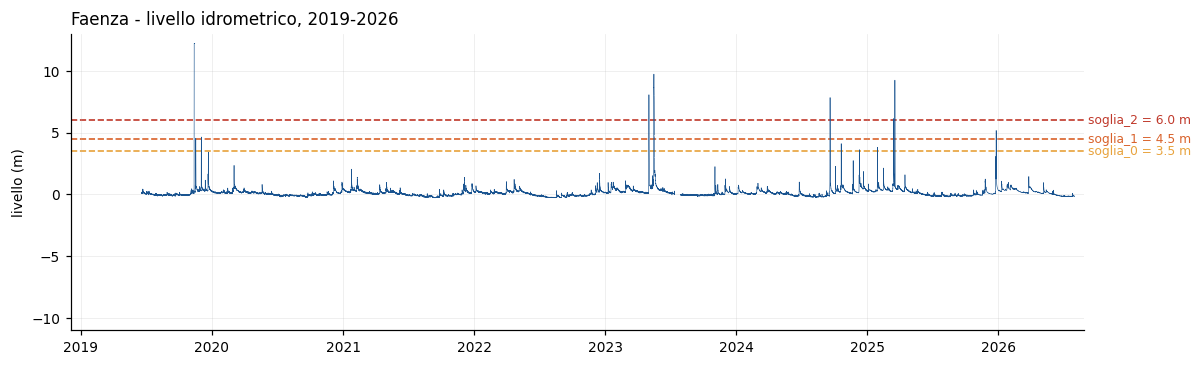

In [31]:
# storico con acquisizione a 15 minuti
_ = idro.grafico_serie(serie_d, SOGLIE, limiti_y=(LIVELLO_MIN, LIVELLO_MAX))

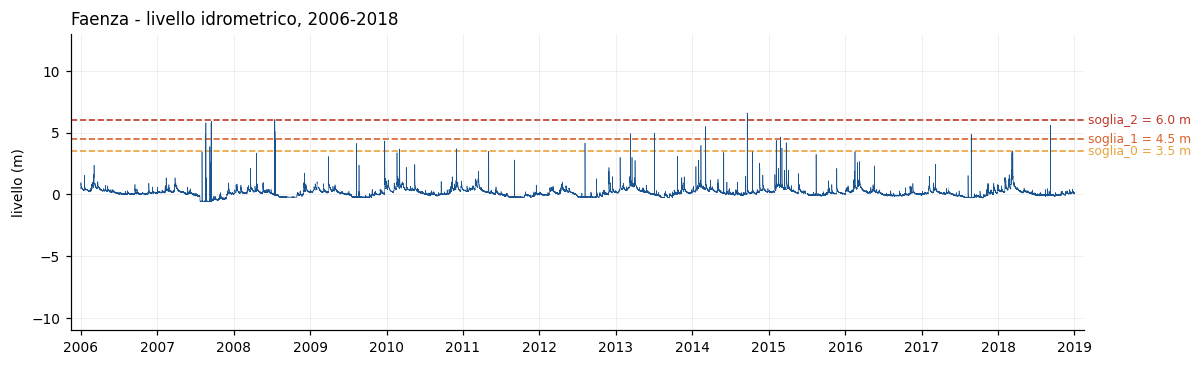

In [33]:
#storico con acquisizione a 30 minuti
_ = idro.grafico_serie(serie_p, SOGLIE, limiti_y=(LIVELLO_MIN, LIVELLO_MAX))

### Copertura mensile

Serve a capire se le lacune sono distribuite uniformemente o concentrate in
periodi specifici. Un calo di copertura in coincidenza con un evento di piena
sarebbe un problema di natura diversa da una lacuna in regime ordinario.

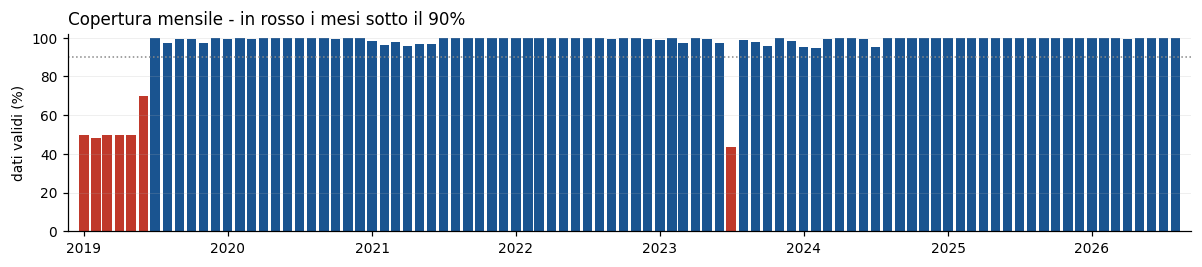

In [34]:
_ = idro.grafico_copertura(serie_d)

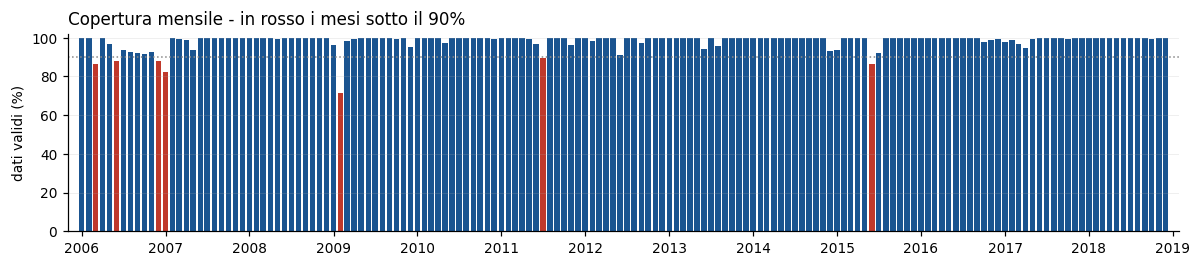

In [35]:
_ = idro.grafico_copertura(serie_p)

### Lacuna piu' estesa

In [38]:
#giorno inizio lacuna dati più estesa
top.inizio

Timestamp('2023-07-13 14:45:00+0000', tz='UTC')

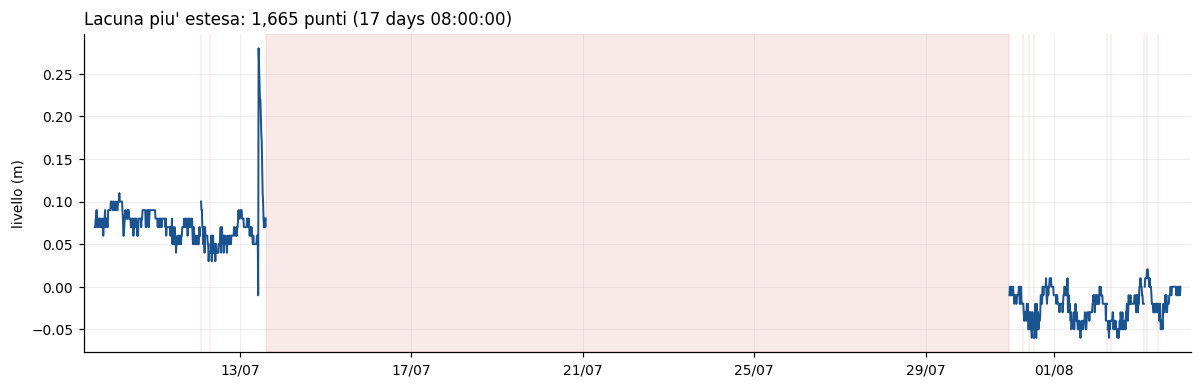

In [36]:
top = buchi.nlargest(1, "n_punti").iloc[0]
_ = idro.grafico_finestra(
    serie_d,
    top.inizio - pd.Timedelta(days=4),
    top.fine + pd.Timedelta(days=4),
    SOGLIE,
    titolo=f"Lacuna piu' estesa: {top.n_punti:,} punti ({top.durata})",
)

### Alluvione del maggio 2023

L'evento del 16-17 maggio 2023 nel bacino del Lamone e' il riferimento naturale
per osservare il comportamento della stazione durante una piena severa.

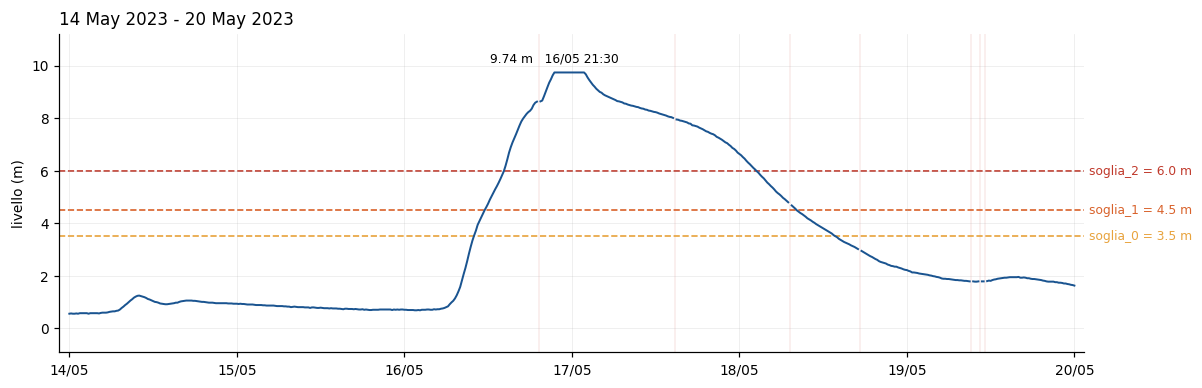

In [39]:
_ = idro.grafico_finestra(serie_d, "2023-05-14", "2023-05-20", SOGLIE)

## 9. Superamenti di soglia

Gli episodi sono sequenze continue sopra la soglia minima, classificate sulla
soglia piu' alta raggiunta: un'onda che arriva a 6,5 m conta una volta sola come
`soglia_2`, non tre volte.

Il parametro `pausa` unisce superamenti ravvicinati. Senza, le oscillazioni
attorno alla soglia spezzano un singolo evento fisico in decine di episodi da un
campione, e il conteggio perde significato.

In [41]:
ep = idro.episodi(serie_d, SOGLIE, pausa="6h")
_ = idro.riepilogo_episodi(ep)

            episodi  quota_pct  picco_max  durata_mediana      durata_max
soglia_max                                                               
soglia_0          3       17.6       4.11 0 days 02:45:00 0 days 03:15:00
soglia_1          8       47.1       5.84 0 days 02:37:30 0 days 21:30:00
soglia_2          6       35.3      12.23 1 days 03:37:30 2 days 03:45:00

totale episodi: 17


In [42]:
ep.nlargest(10, "picco")

,inizio,fine,durata,picco,n_campioni,soglia_max
5,2019-11-12 19:45:00+00:00,2019-11-14 14:30:00+00:00,1 days 18:45:00,12.23,167,soglia_2
9,2023-05-16 10:00:00+00:00,2023-05-18 13:45:00+00:00,2 days 03:45:00,9.74,205,soglia_2
15,2025-03-18 13:30:00+00:00,2025-03-18 13:30:00+00:00,0 days 00:00:00,9.25,1,soglia_2
8,2023-05-02 11:30:00+00:00,2023-05-03 23:15:00+00:00,1 days 11:45:00,8.07,144,soglia_2
10,2024-09-18 13:00:00+00:00,2024-09-19 08:30:00+00:00,0 days 19:30:00,7.84,68,soglia_2
14,2025-03-14 08:45:00+00:00,2025-03-15 02:30:00+00:00,0 days 17:45:00,6.14,72,soglia_2
4,2019-05-12 23:00:00+00:00,2019-05-13 20:30:00+00:00,0 days 21:30:00,5.84,44,soglia_1
3,2019-04-16 05:30:00+00:00,2019-04-16 05:30:00+00:00,0 days 00:00:00,5.59,1,soglia_1
16,2025-12-25 11:00:00+00:00,2025-12-26 00:45:00+00:00,0 days 13:45:00,5.18,56,soglia_1
2,2019-02-01 13:00:00+00:00,2019-02-01 13:00:00+00:00,0 days 00:00:00,5.14,1,soglia_1


### Ripartizione dei campioni

Quanto tempo la stazione trascorre in ciascuna fascia. E' la misura diretta dello
sbilanciamento del problema.

In [43]:
idro.distribuzione(serie_d, SOGLIE)

,campioni,quota_pct,ore
valore,,,
sotto soglia,253216,99.6662,63304.0
soglia_0,228,0.0897,57.0
soglia_1,191,0.0752,47.8
soglia_2,429,0.1689,107.2


## 10. Controllo di qualita' dei valori

controllo discontinuità tra acquisiizoni, prima analisi con una valore di default di SALTO_MAX

In [44]:
# variazione massima potenzialmente plausibile fra due campioni consecutivi
SALTO_MAX = 1.0

brusche = idro.variazioni_brusche(serie_d, SALTO_MAX)
brusche.head(10)

variazioni oltre 1.0 m fra campioni consecutivi: 3


,timestamp,valore_prec,valore,variazione,dopo_lacuna
0,2019-11-12 19:45:00+00:00,0.28,12.23,11.95,True
1,2025-03-18 13:30:00+00:00,0.66,9.25,8.59,True
2,2025-03-18 13:45:00+00:00,9.25,0.67,8.58,False


In [45]:
spike = idro.spike_isolati(serie_d, SALTO_MAX)
spike.head(10)

spike isolati (scostamento > 1.0 m da entrambi i vicini): 6
di cui sopra la soglia minima: 5  (genererebbero falsi superamenti)


,timestamp,valore_prec,valore,valore_succ,origine
1308,2019-01-14 15:00:00+00:00,0.07,4.86,0.07,osservato
1672,2019-01-18 10:00:00+00:00,0.05,4.93,0.05,osservato
3028,2019-02-01 13:00:00+00:00,0.37,5.14,0.42,osservato
10102,2019-04-16 05:30:00+00:00,0.31,5.59,0.32,osservato
168720,2023-10-24 12:00:00+00:00,-0.01,-10.72,0.10,osservato
217782,2025-03-18 13:30:00+00:00,0.66,9.25,0.67,osservato


Presenza di spike e valori anomali ma improbabile che siano dati da una piena, più probabile lettura anomala del sensore

In [46]:
sospetti = idro.episodi_sospetti(ep, min_campioni=4)
sospetti

episodi con meno di 4 campioni: 5 su 17
soglia_max
soglia_0    0
soglia_1    4
soglia_2    1


,inizio,fine,durata,picco,n_campioni,soglia_max
0,2019-01-14 15:00:00+00:00,2019-01-14 15:00:00+00:00,0 days,4.86,1,soglia_1
1,2019-01-18 10:00:00+00:00,2019-01-18 10:00:00+00:00,0 days,4.93,1,soglia_1
2,2019-02-01 13:00:00+00:00,2019-02-01 13:00:00+00:00,0 days,5.14,1,soglia_1
3,2019-04-16 05:30:00+00:00,2019-04-16 05:30:00+00:00,0 days,5.59,1,soglia_1
15,2025-03-18 13:30:00+00:00,2025-03-18 13:30:00+00:00,0 days,9.25,1,soglia_2


In [47]:
# confronto fra il conteggio grezzo e quello al netto degli episodi sospetti
confronto = pd.DataFrame({
    "grezzi": ep.soglia_max.value_counts(),
    "plausibili": ep[ep.n_campioni >= 4].soglia_max.value_counts(),
}).fillna(0).astype(int).sort_index()
confronto["scartati"] = confronto.grezzi - confronto.plausibili
confronto

,grezzi,plausibili,scartati
soglia_max,,,
soglia_0,3,3,0
soglia_1,8,4,4
soglia_2,6,5,1


## 11. Considerazioni

La serie e' utilizzabile, ma non nella forma in cui viene scaricata. Questa prima
esplorazione ha fatto emergere diverse complessita' che condizionano
l'impostazione della Fase 1 e sono propedeutiche da gestire per la previsione su timeseries.

### 11.1 Due regimi di campionamento, non uno

La stazione registra a 30 minuti fino al 2018 e a 15 minuti dal 1 gennaio 2019.
Il cambio e' netto (100% di intervalli uniformi in ogni anno, nessuna zona di
transizione), il che semplifica il trattamento ma impone una scelta.

Applicare una griglia unica a 15 minuti sull'intero ventennio avrebbe prodotto
circa 175.000 valori mancanti fittizi, cioe' un punto su due nel periodo
antecedente: un artefatto che sarebbe stato facilmente scambiato per un problema
di copertura. I due periodi vanno quindi trattati come serie distinte ma potrebbe non essere l'opzione migliore.

La conseguenza pratica e' che il periodo utilizzabile per un modello a passo di
15 minuti parte dal 2019: **sette anni e mezzo**, non venti. Il periodo
precedente resta disponibile a risoluzione oraria o semioraria, utile come
confronto ma non per lo stesso modello.

In alternativa si potrrebbe procedere con un campionamento su tutto il periodo a 15 minuti replicanto nel periodo a 30 minuti l'acqusizione precedente (però introdurrebbe dei valori "sintetici" non necessariamente reali, altro spunto è, in base ai dati a 15 minuti ricostruire un pattern per colmare l'acquisizione a 15 minuti assente nel passato (ovvero capire meglio il metodo di interpolazione più idoneo. Invine, si potrebbe adottare un'acquisizione sempre a 30 minuti senza condizionamento di azioni sintetiche sui dati.



### 11.2 La copertura peggiora nel periodo recente

Il periodo a 15 minuti ha il **4,42% di valori
mancanti** contro l'**1,56%** del periodo a 30 minuti. La frequenza di
acquisizione e' aumentata, l'affidabilita' della trasmissione potezialmente è  rimasta invariata.

La distribuzione delle lacune spiega solo in parte il fenomeno: gran parte delle sequenze non disponibili sono da un singolo punto, quindi si potrebbe trattare potenzialmente, nella maggior parte dei casi, di perdite
sporadiche di pacchetto, non di fermi prolungati. Restano pero' alcune sequenze
lunghe, e la piu' estesa merita attenzionnr, due mesi dopo l'alluvione di maggio che ha interessato proprio
questo bacino. E' un'ipotesi da verificare, ma la coincidenza temporale suggerisce
un intervento sulla strumentazione successivo all'evento. (cosa potenzialmente normale e che potrebbe verificarsi su moolti bacini essendo strumenti sottoposti a manutenzione).

### 11.3 Spike strumentali che generano falsi superamenti

Le variazioni piu' ampie fra campioni consecutivi non corrispondono a piene:
cadono su lacune di un solo punto, e il valore che segue la lacuna e' isolato,
alto, e immediatamente seguito dal ritorno al livello di magra.

Questi valori compaiono nella tabella degli episodi come superamenti a tutti gli
effetti: spesso episodi che si riferiscono ad una sola acquisizione.
Contarli come piene significherebbe gonfiare del 20% circa la classe positiva con
guasti del sensore e sarebbe scorretto.

### 11.4 Sbilanciamento estremo, ma non ingestibile

I campioni sopra la prima soglia sono circa lo **0,3% del totale**. Espresso in
termini piu' concreti: su sette anni e mezzo di registrazioni continue, il fiume
si trova sopra la soglia di allarme per poche decine di ore complessive, ed è proprio in quesi casi che il sistema deve funzionare.

Il conteggio piu' utile e' pero' quello degli **episodi**, non dei campioni,
perche' l'unita' su cui un modello di allertamento viene valutato e' l'evento, non
il singolo quarto d'ora.

Si aggiunge quindi la complessità dello sbilaniamento, noto, dei dati che rende il problema stimolante ma allo stesso tempo complesso e dove sicuramente un'unica stazione non è abbastanza per gestire il sistema.

## 12. Cosa comporta per il seguito

Le complessita' emerse non sono ostacoli imprevisti: sono il tipo di problema che
ci si aspetta di trovare su dati operativi reali, e conoscerne l'entita' adesso
evita di scoprirla a modello gia' addestrato. Vale pero' la pena fissare le
conseguenze.

**Sul controllo di qualita'.** Il filtraggio degli spike deve precedere qualunque
altra operazione, ed e' bene che sia un passo documentato e riproducibile, non una
correzione manuale. Il criterio proposto (variazione superiore a un metro fra
campioni consecutivi, con scostamento nella stessa direzione da entrambi i vicini
validi) andra' calibrato sulle altre stazioni prima di essere adottato.

**Sull'imputazione.** La distribuzione delle lacune suggerisce una strategia
differenziata piuttosto che una regola unica: le sequenze da un punto sono
interpolabili senza rischio apprezzabile, quelle di alcune ore richiedono
cautela e la verifica del salto agli estremi, quelle di giorni vanno escluse
dai periodi utilizzabili anziche' ricostruite. Nessuna imputazione andrebbe
applicata in prossimita' di un superamento senza prima verificare che non stia
cancellando la dinamica che si vuole prevedere.

**Sulla selezione delle stazioni.** Il criterio non puo' essere la sola lunghezza
dello storico: contano la continuita' durante gli eventi, la presenza di stazioni
a monte utilizzabili come predittori, e la numerosita' dei superamenti storici.


### Passi successivi

1. estendere l'analisi alle stazioni a monte sul Lamone e ad altri bacini romagnoli
2. incrociare le lacune con le date degli eventi documentati, per rispondere alla
   domanda sulla copertura durante le piene
3. calibrare le soglie del controllo di qualita' su piu' stazioni
4. verificare i valori estremi contro fonti indipendenti
5. costruire il primo insieme di addestramento multi-stazione e quantificare il
   numero effettivo di episodi disponibili